# Screening Supplement

In this notebook we visualize our results for various screening simulation experients.

We begin by importing required packages.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.optimize as opt
import statistics
from scipy import stats
import ptitprince as pt
import os
import re
import csv 
from datetime import date
from statannotations.Annotator import Annotator
from sklearn import metrics


# Our libraries
import libraries.disturbances as dt
import libraries.normalization as nrm
import libraries.utilities as util
import libraries.screening as sc

In [3]:
fig_dir = 'generated-plots/screening-supplement/'
data_dir = 'generated-data/screening/'

# Visual Examples

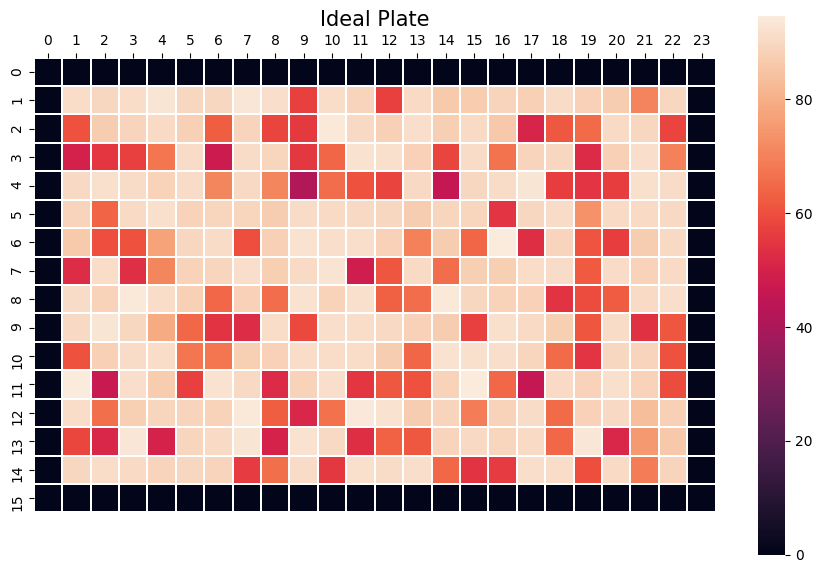

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1545: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_df = pd.pivot_table(unstack_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


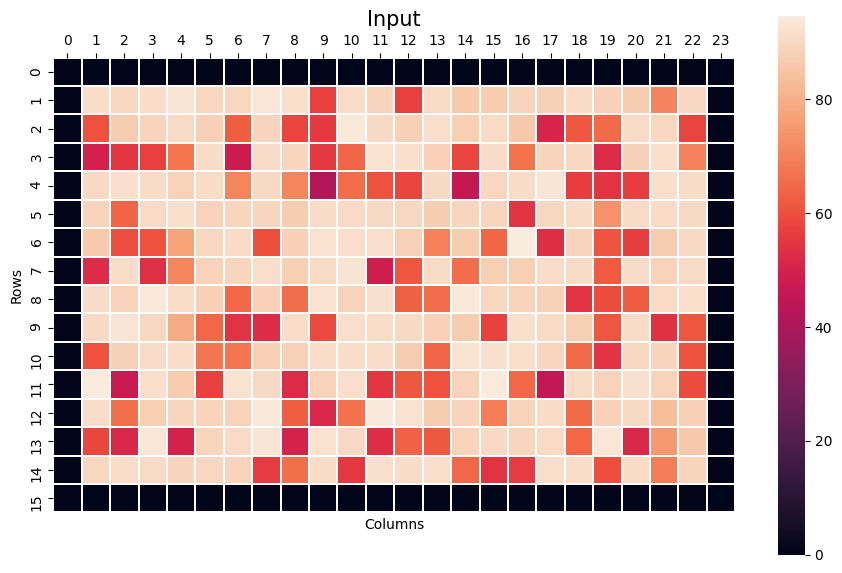

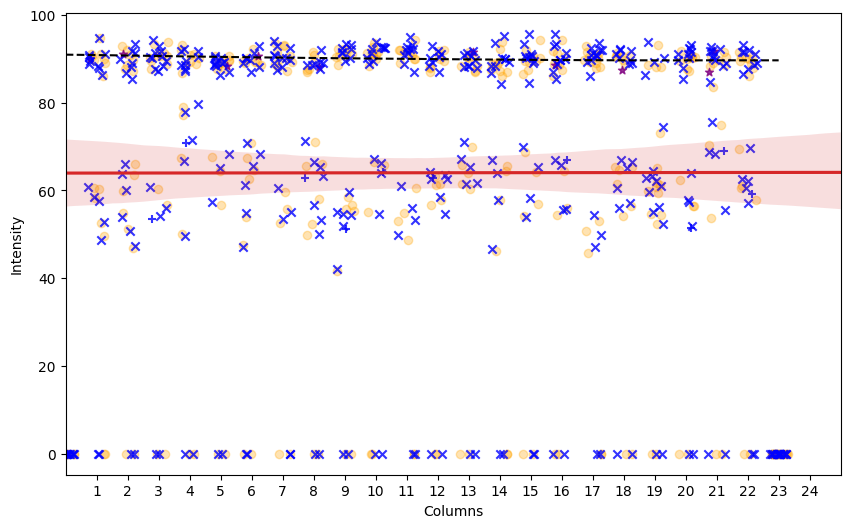

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1603: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_adjusted_df = pd.pivot_table(unstack_adjusted_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


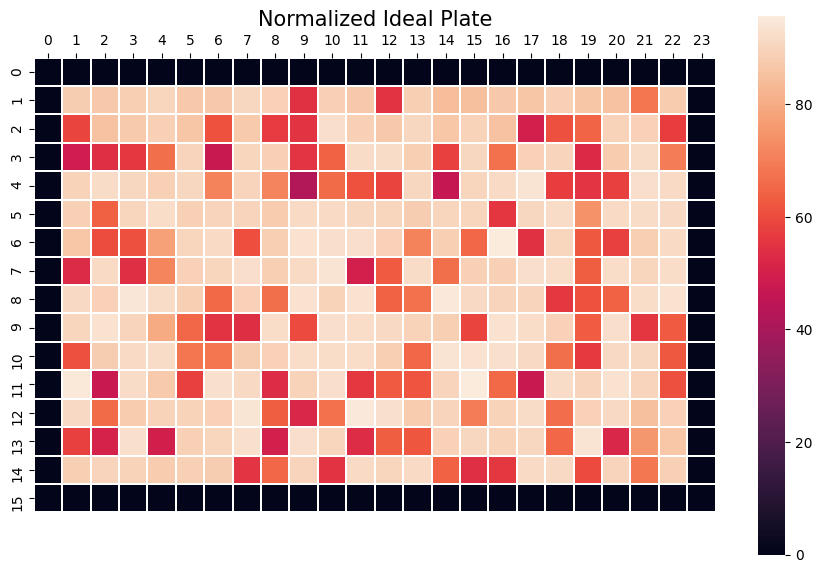

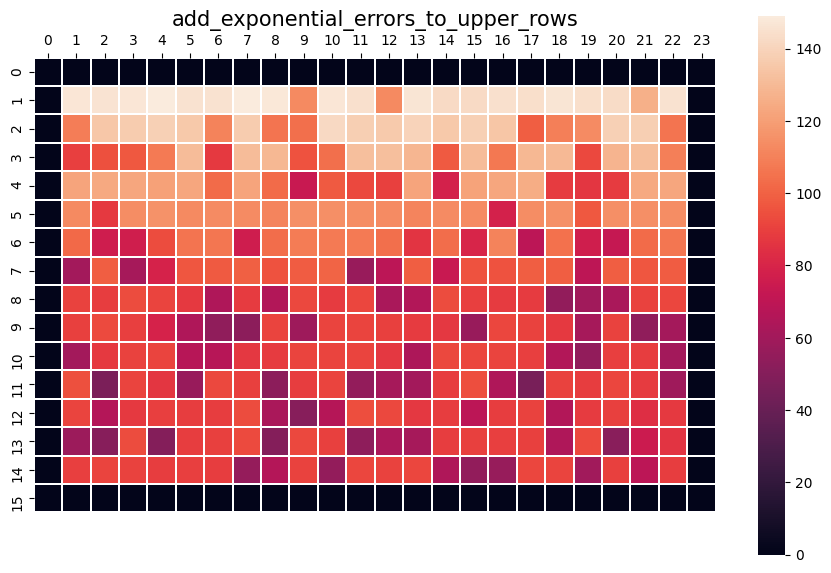

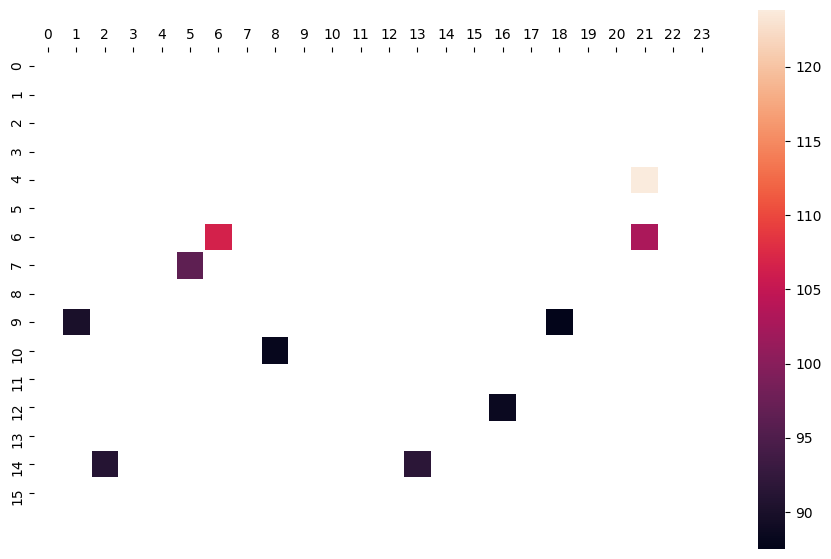

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1545: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_df = pd.pivot_table(unstack_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


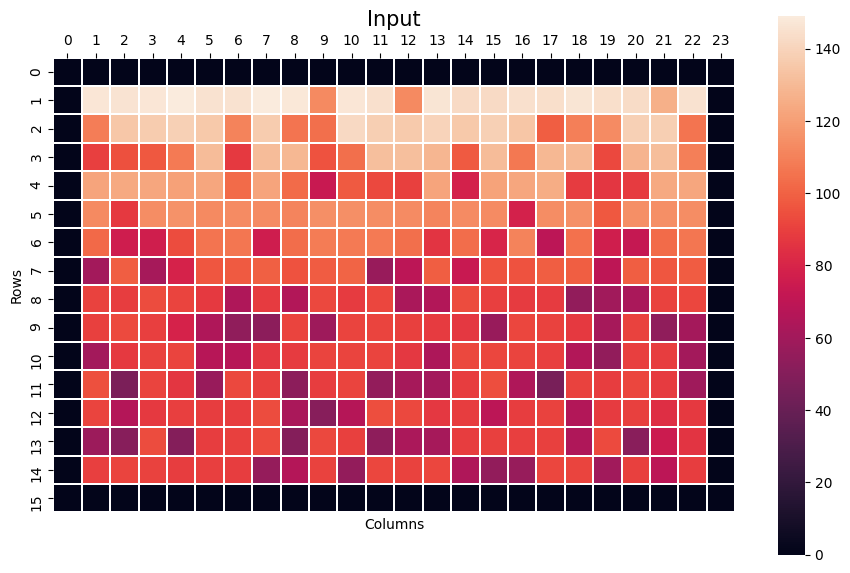

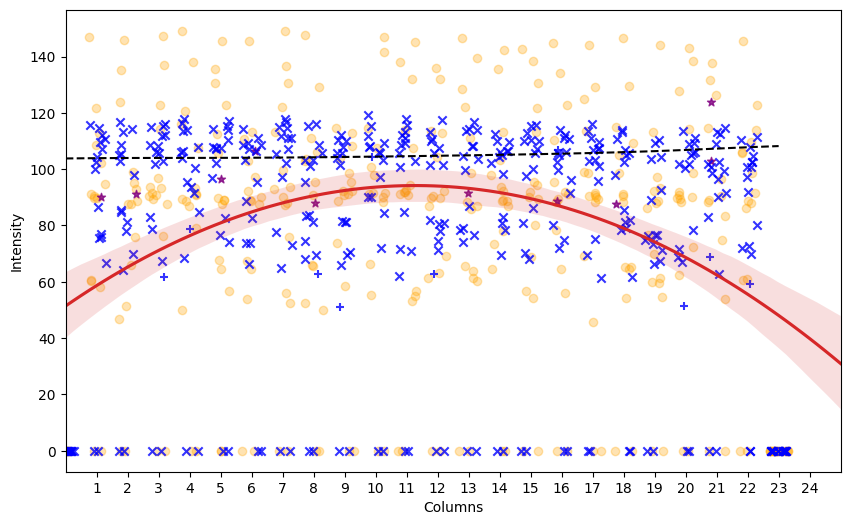

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1603: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_adjusted_df = pd.pivot_table(unstack_adjusted_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


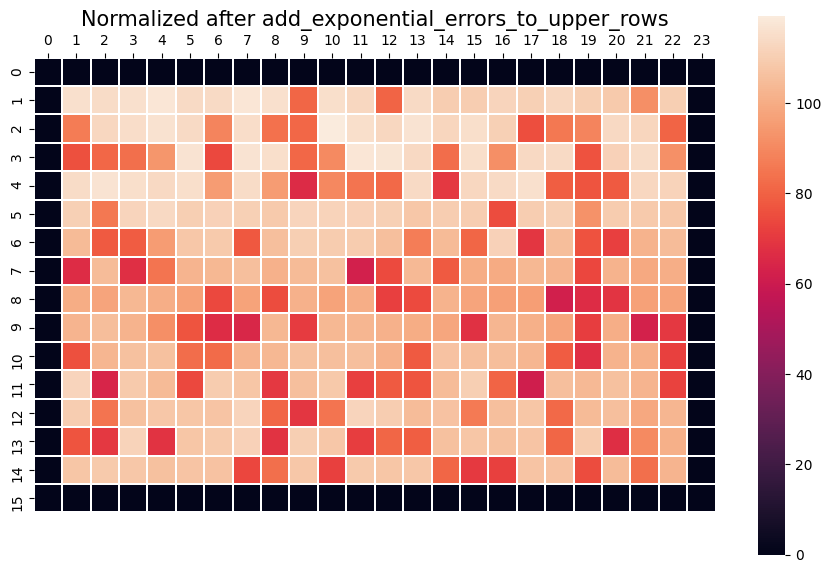

In [5]:
layout_dir = 'layouts/screening_RANDM_layouts/'
layout_file = 'plate_layout_rand_10-10_02.npy'

layout = np.load(layout_dir+layout_file)  
            
neg_control_id = np.max(layout)
pos_control_id = neg_control_id -1 

neg_control_mean = 90
pos_control_mean = 60
neg_stdev = 2
pos_stdev = 7

np.random.seed(42)

ideal_plate, _ = sc.fill_plate(layout,neg_control_id,pos_control_id,neg_control_mean,pos_control_mean,neg_stdev,pos_stdev)
util.plot_plate(pd.DataFrame(ideal_plate), title="Ideal Plate")
norm_plate = util.plot_well_series(ideal_plate,layout,neg_control_id,pos_control_id,order=1,filename=fig_dir+'random-none')
util.plot_plate(pd.DataFrame(norm_plate), title="Normalized Ideal Plate")

disturbed_plate = dt.add_linear_errors_to_upper_rows_half(ideal_plate, 4)
util.plot_plate(pd.DataFrame(disturbed_plate), title="add_exponential_errors_to_upper_rows")

control_locations=util.get_controls_layout(layout)
util.plot_plate(disturbed_plate, title="", mask=np.array(1-control_locations,dtype=bool), filename = fig_dir+"random-controls-rows-error.png")

norm_plate = util.plot_well_series(disturbed_plate,layout,neg_control_id,pos_control_id,order=2,vmin=None,vmax=None,filename=fig_dir+'norm_plate_random')
util.plot_plate(pd.DataFrame(norm_plate), title="Normalized after add_exponential_errors_to_upper_rows")


/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1545: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_df = pd.pivot_table(unstack_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


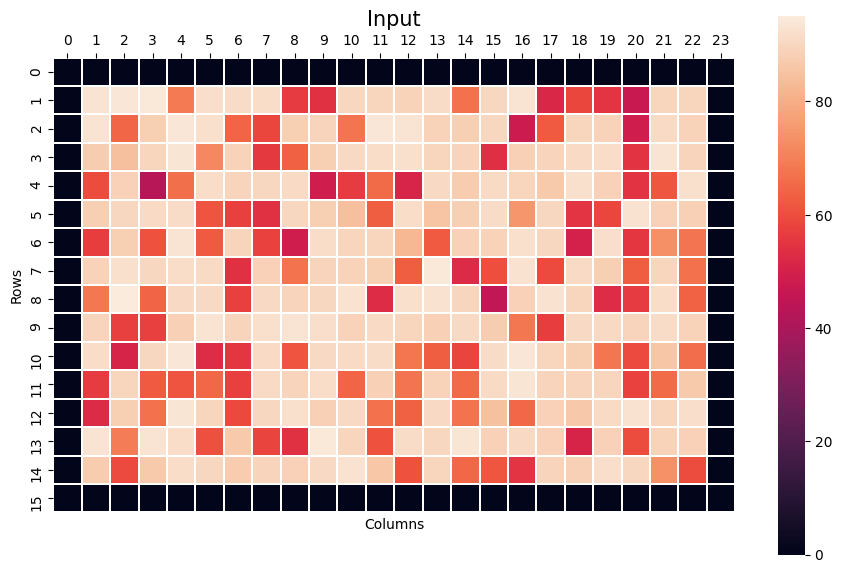

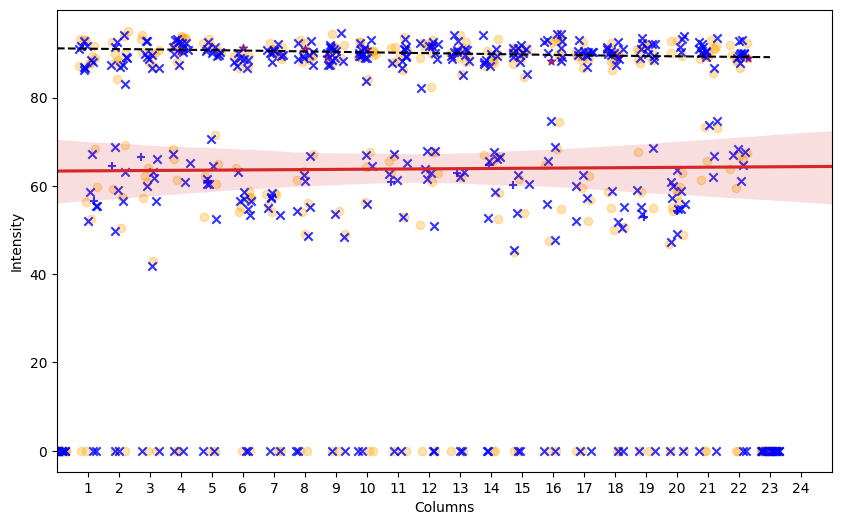

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1603: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_adjusted_df = pd.pivot_table(unstack_adjusted_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


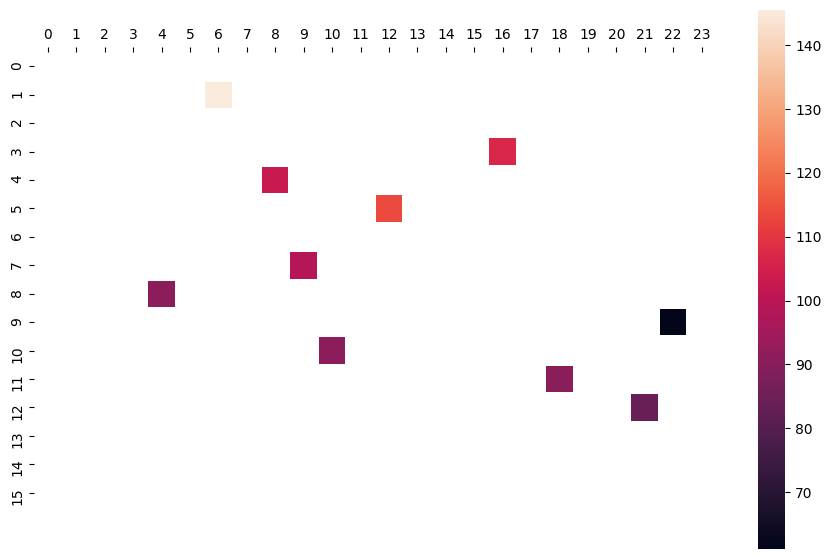

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1545: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_df = pd.pivot_table(unstack_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


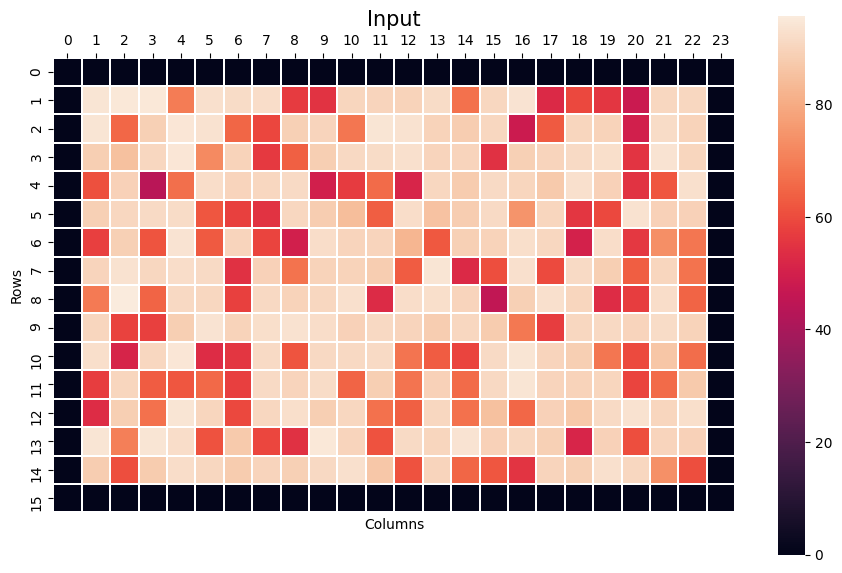

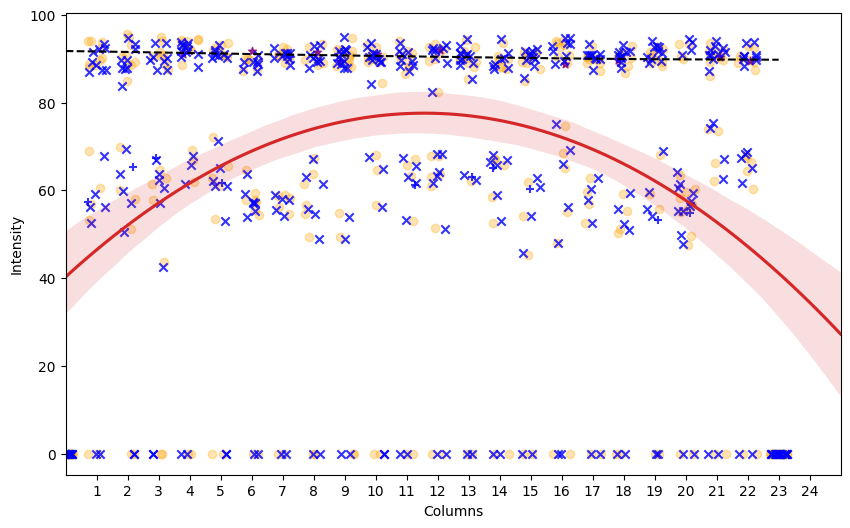

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1603: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_adjusted_df = pd.pivot_table(unstack_adjusted_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , 92.35790018, 93.34637671, 93.52392467, 67.92851662,
        91.58621665, 90.78864646, 91.22245077, 55.86603044, 54.05213951,
        89.82489191, 89.54068509, 89.02169586, 91.41590332, 66.85288982,
        90.48195338, 93.39470501, 52.57503911, 59.328126  , 55.76938625,
        47.80966205, 90.78607071, 90.78150227,  0.        ],
       [ 0.        , 92.37680944, 63.8261024 , 87.42877354, 93.25436781,
        92.05638867, 63.75450616, 58.1565696 , 87.88168166, 89.11134782,
        67.52911084, 93.72645662, 93.09086869, 89.12165926, 88.00274817,
        90.66314178, 48.13679896, 62.90526658, 90.46476672, 89.93129917,
  

In [6]:
layout_dir = 'layouts/screening_PLAID_layouts/'
layout_file = 'plate_layout_10-10_01.npy'

layout = np.load(layout_dir+layout_file)  
            
neg_control_id = np.max(layout)
pos_control_id = neg_control_id -1 

neg_control_mean = 90
pos_control_mean = 60
neg_stdev = 2
pos_stdev = 7

ideal_plate, _ = sc.fill_plate(layout,neg_control_id,pos_control_id,neg_control_mean,pos_control_mean,neg_stdev,pos_stdev)
plate_df = pd.DataFrame(ideal_plate)


util.plot_well_series(plate_df,layout,neg_control_id,pos_control_id,filename='PLAID-none')

control_locations=util.get_controls_layout(layout)
util.plot_plate(disturbed_plate, title="", mask=np.array(1-control_locations,dtype=bool), filename = fig_dir+"plaid-controls-rows-error.png")


disturbed_plate = dt.add_bowlshaped_errors(ideal_plate, 0.05)
util.plot_well_series(pd.DataFrame(disturbed_plate),layout,neg_control_id,pos_control_id,order=2,filename=fig_dir+'PLAID-bowlshape',vmin=None,vmax=None)


/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1545: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_df = pd.pivot_table(unstack_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


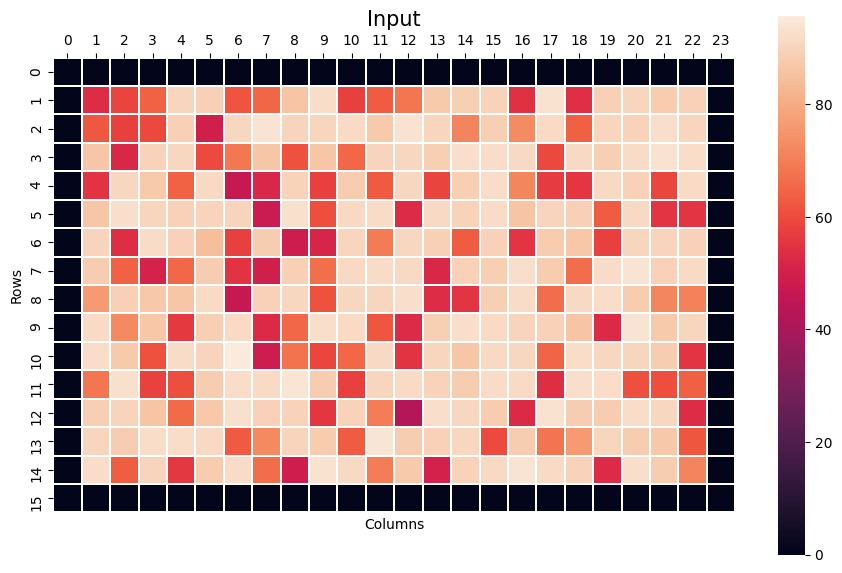

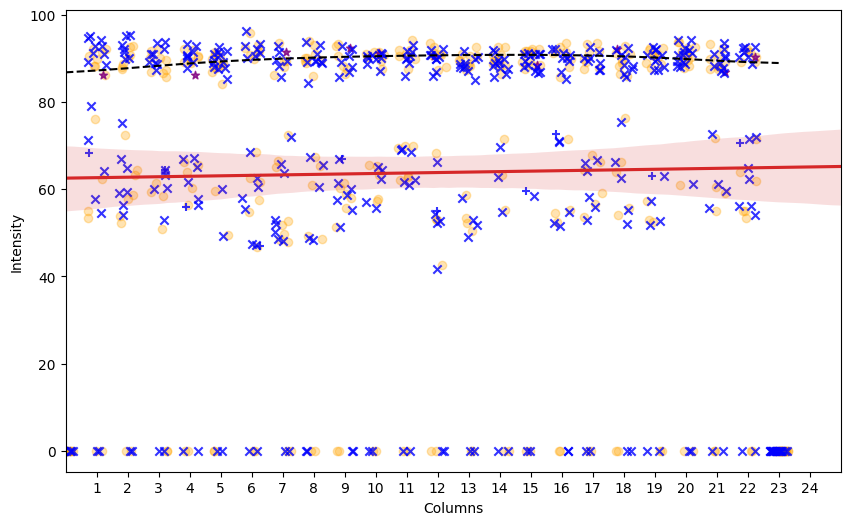

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1603: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_adjusted_df = pd.pivot_table(unstack_adjusted_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


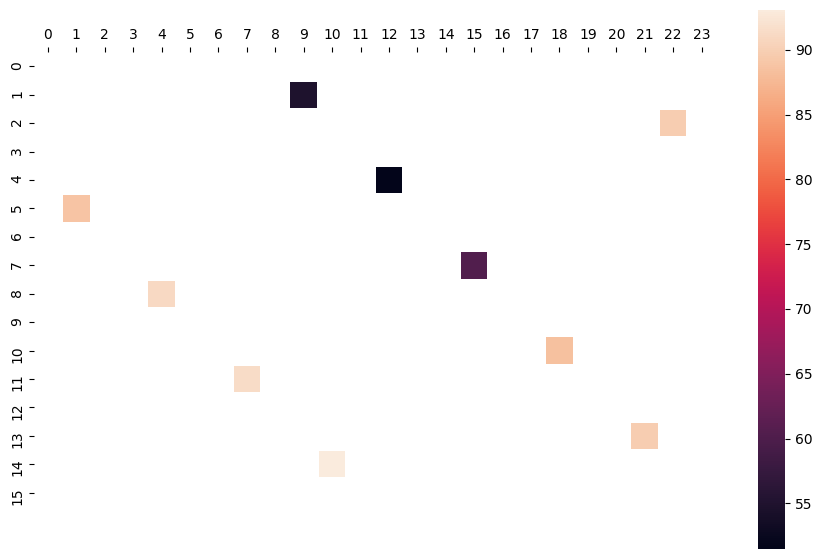

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1545: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_df = pd.pivot_table(unstack_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


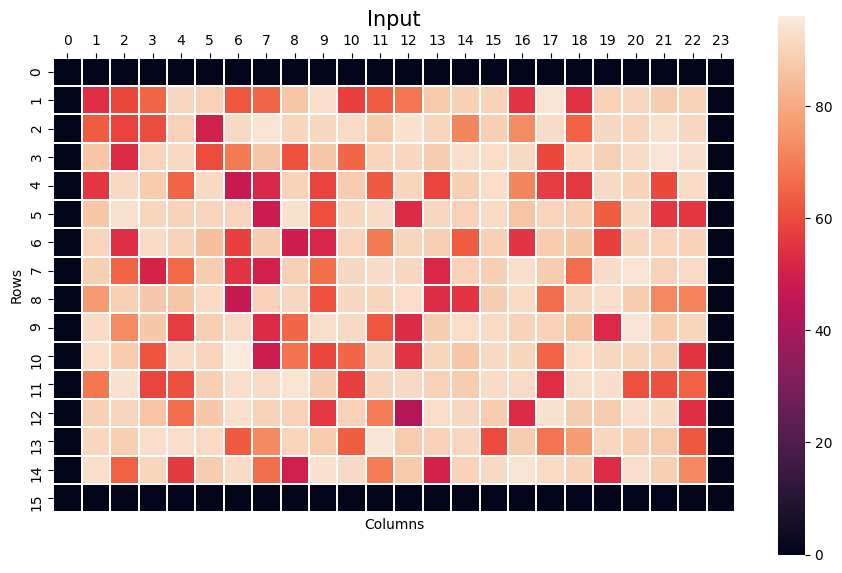

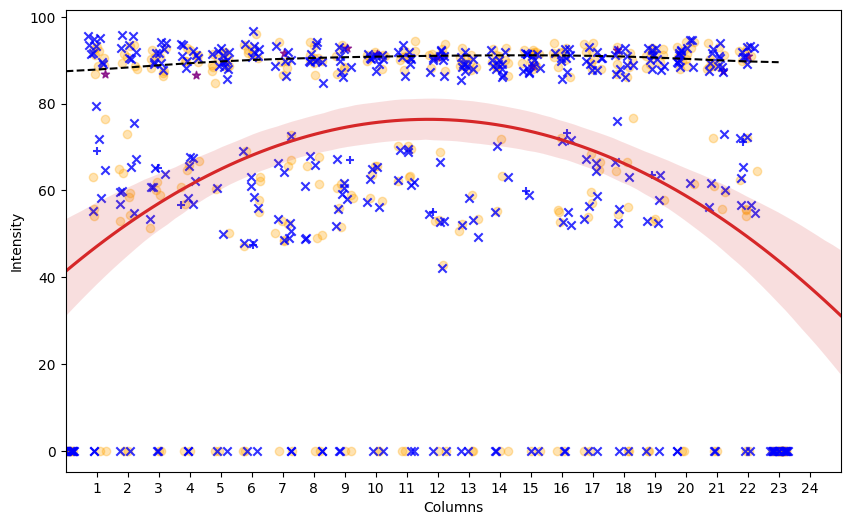

/Users/ramgi410/Documents-Local/eclipse_workspace/compd_evaluation/libraries/utilities.py:1603: FutureWarning: The provided callable <function sum at 0x1065efec0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  unstacked_adjusted_df = pd.pivot_table(unstack_adjusted_df, values='Intensity', index=['Rows'],columns=['Columns'], aggfunc=np.sum)


array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , 55.16167851, 59.93006863, 65.08388015, 90.59703481,
        88.65282301, 61.01536332, 64.1354323 , 84.77446235, 90.97521151,
        56.11794122, 61.29029494, 66.55503249, 85.36592431, 86.70145612,
        87.5870451 , 52.76387194, 91.86000408, 52.59907358, 87.76610566,
        89.63352516, 87.19507205, 89.13501792,  0.        ],
       [ 0.        , 64.74327043, 59.66661588, 60.77895008, 89.84471579,
        49.84488452, 90.70932604, 93.26332104, 89.5314393 , 89.72788275,
        90.47746103, 86.39349555, 92.19962447, 89.13422043, 70.16362755,
        87.31836763, 71.59687118, 90.56073305, 63.08804997, 89.96553926,
  

In [7]:
layout_dir = 'layouts/screening_COMPD_layouts/'
layout_file = 'plate_layout_10-10_01.npy'

layout = np.load(layout_dir+layout_file)  
            
neg_control_id = np.max(layout)
pos_control_id = neg_control_id -1 

neg_control_mean = 90
pos_control_mean = 60
neg_stdev = 2
pos_stdev = 7

ideal_plate, _ = sc.fill_plate(layout,neg_control_id,pos_control_id,neg_control_mean,pos_control_mean,neg_stdev,pos_stdev)
plate_df = pd.DataFrame(ideal_plate)


util.plot_well_series(plate_df,layout,neg_control_id,pos_control_id,filename='COMPD-none')

control_locations=util.get_controls_layout(layout)
util.plot_plate(disturbed_plate, title="", mask=np.array(1-control_locations,dtype=bool), filename = fig_dir+"COMPD-controls-rows-error.png")


disturbed_plate = dt.add_bowlshaped_errors(ideal_plate, 0.05)
util.plot_well_series(pd.DataFrame(disturbed_plate),layout,neg_control_id,pos_control_id,order=2,filename=fig_dir+'COMPD-bowlshape',vmin=None,vmax=None)


# Data Plots

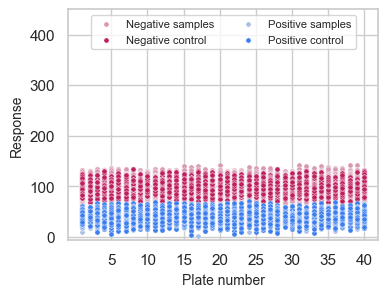

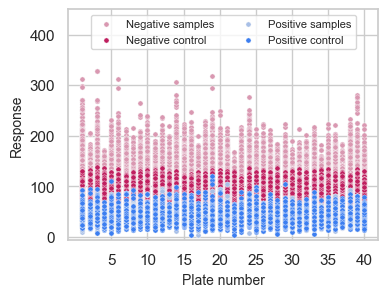

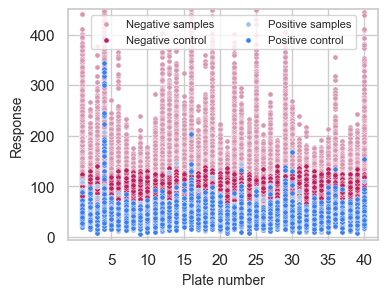

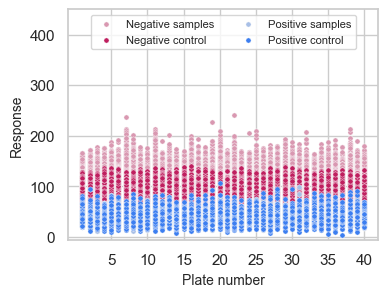

In [9]:
# Manuscript Figure 3 a, b, c
fig_name = "0.06-10-10-0.99-stdev-3-4"
#residuals_filename = data_dir+'screening-residuals-10-10-0.06-pna-0.99-20221102-stdev-3-4.csv'
residuals_filename = data_dir+'screening-residuals-10-10-0.1-pna-0.99-20250623-ROC-supplement.csv'

util.plot_screening_plates(residuals_filename, fig_name=fig_name, fig_dir=fig_dir,max_value=450)

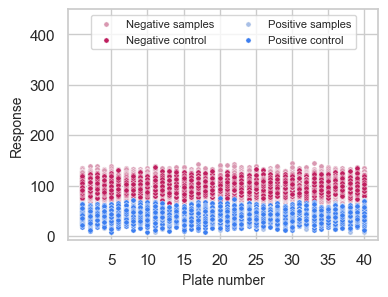

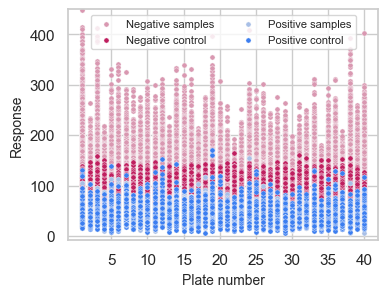

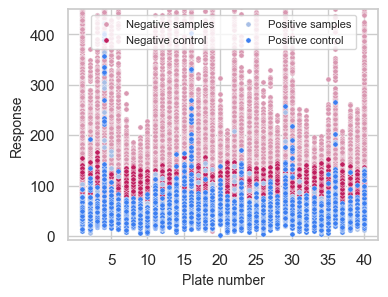

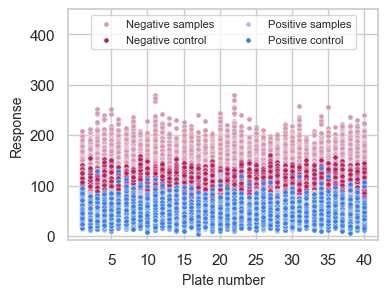

In [10]:
# Supplement Figure 20?
fig_name = "0.08-10-10-0.99-stdev-3-4"
residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.99-20250623-ROC-supplement.csv'

util.plot_screening_plates(residuals_filename, fig_name=fig_name, fig_dir=fig_dir,max_value=450)

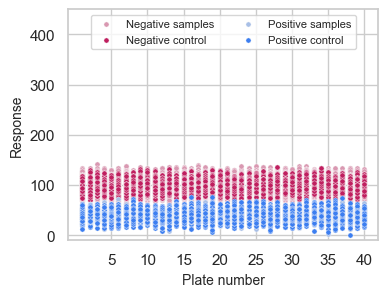

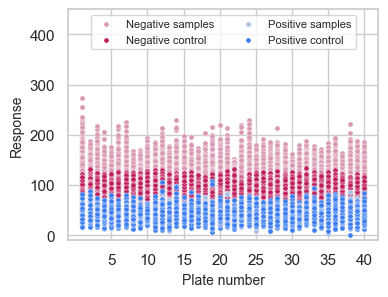

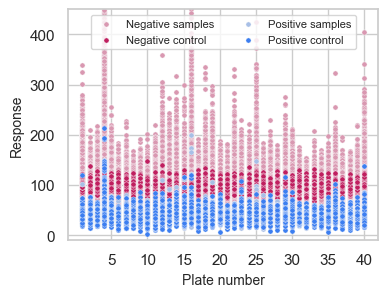

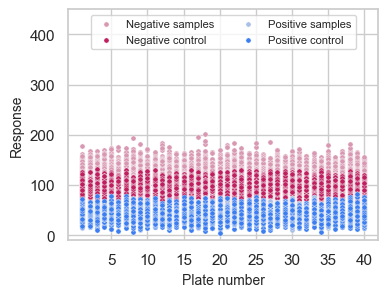

In [11]:
# Supplement Figure not included
fig_name = "0.03-10-10-0.99-stdev-3-4"
residuals_filename = data_dir+'screening-residuals-10-10-0.06-pna-0.99-20250623-ROC-supplement.csv'

util.plot_screening_plates(residuals_filename, fig_name=fig_name, fig_dir=fig_dir,max_value=450)

In [12]:
# Supplement Figure not included
fig_name = "0.05-10-10-0.99-stdev-3-4"
residuals_filename = data_dir+'screening-residuals-10-10-0.05-pna-0.99-20250623-ROC-supplement.csv'

util.plot_screening_plates(residuals_filename, fig_name=fig_name, fig_dir=fig_dir,max_value=250)

FileNotFoundError: [Errno 2] No such file or directory: 'generated-data/screening/screening-residuals-10-10-0.05-pna-0.99-20250623-ROC-supplement.csv'

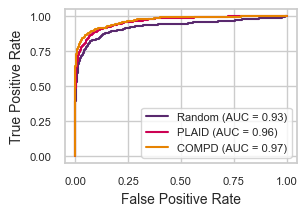

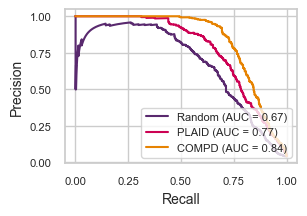

Mean and std of RANDOM layouts: 0.93  $\pm$ (0.004)
Mean and std of PLAID layouts: 0.96  $\pm$ (0.002)
Mean and std of COMPD layouts: 0.97  $\pm$ (0.002)

Variance of RANDOM layouts: 1.832630506411188e-05
Variance of PLAID layouts: 2.8264796184003687e-06
Variance of COMPD layouts: 5.4706307425243715e-06 

Case of equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=19.231075832621496, pvalue=1.893128909105409e-13, df=18.0)
RANDOM vs COMPD layouts: TtestResult(statistic=24.781992705049838, pvalue=2.312077270694192e-15, df=18.0)
PLAID vs COMPD layouts: TtestResult(statistic=-11.263405414377605, pvalue=1.3894807417498061e-09, df=18.0) 

Case of not equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=19.231075832621496, pvalue=3.196662847684943e-10, df=11.7116509749039)
RANDOM vs COMPD layouts: TtestResult(statistic=24.781992705049838, pvalue=6.362503644130773e-13, df=13.933593567915533)
PLAID vs COMPD layouts: TtestResult(statistic=-11.263405414377607, pvalue=4.073313

In [20]:
# In the manuscript (Figure 3f)
residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.99-20250623-ROC-supplement.csv'

fig_name = '10-10-0.2-1.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=6)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=6)

util.roc_table_code(residuals_filename)
print('--------------')
util.pr_table_code(residuals_filename)

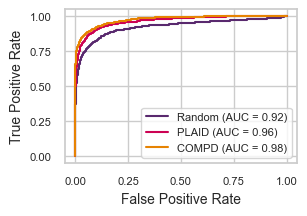

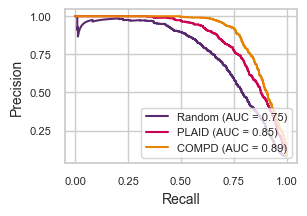

Mean and std of RANDOM layouts: 0.93  $\pm$ (0.007)
Mean and std of PLAID layouts: 0.96  $\pm$ (0.004)
Mean and std of COMPD layouts: 0.98  $\pm$ (0.002)

Variance of RANDOM layouts: 4.307517483639755e-05
Variance of PLAID layouts: 1.5346577092706496e-05
Variance of COMPD layouts: 3.960642218604761e-06 

Case of equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=13.317485934029179, pvalue=9.27062944843949e-11, df=18.0)
RANDOM vs COMPD layouts: TtestResult(statistic=21.833712846857768, pvalue=2.1076332478600032e-14, df=18.0)
PLAID vs COMPD layouts: TtestResult(statistic=-10.91269966143144, pvalue=2.2913853761132276e-09, df=18.0) 

Case of not equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=13.317485934029175, pvalue=1.3370094233743382e-09, df=14.690619069665837)
RANDOM vs COMPD layouts: TtestResult(statistic=21.83371284685777, pvalue=3.512136241060638e-10, df=10.641174842519652)
PLAID vs COMPD layouts: TtestResult(statistic=-10.91269966143144, pvalue=4.9831367

In [22]:
# In the manuscript (Figure 3g)
residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.95-20250623-ROC-supplement.csv'

fig_name = '10-10-0.2-5.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=9)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=9)

util.roc_table_code(residuals_filename)
print('--------------')
util.pr_table_code(residuals_filename)

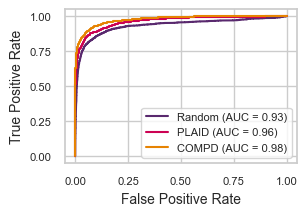

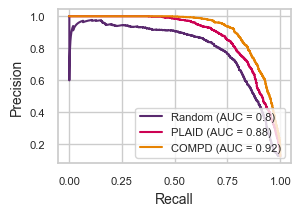

Mean and std of RANDOM layouts: 0.93  $\pm$ (0.004)
Mean and std of PLAID layouts: 0.96  $\pm$ (0.002)
Mean and std of COMPD layouts: 0.98  $\pm$ (0.002)

Variance of RANDOM layouts: 1.480436856685447e-05
Variance of PLAID layouts: 4.4971425811568e-06
Variance of COMPD layouts: 3.434121967813128e-06 

Case of equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=23.298663006056273, pvalue=6.8018774953796484e-15, df=18.0)
RANDOM vs COMPD layouts: TtestResult(statistic=34.063904941294076, pvalue=8.457976302584032e-18, df=18.0)
PLAID vs COMPD layouts: TtestResult(statistic=-15.309728841700089, pvalue=9.152200449223272e-12, df=18.0) 

Case of not equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=23.298663006056273, pvalue=1.3342096847228213e-12, df=14.005949667963455)
RANDOM vs COMPD layouts: TtestResult(statistic=34.06390494129408, pvalue=4.544922275996678e-14, df=12.962201842737377)
PLAID vs COMPD layouts: TtestResult(statistic=-15.309728841700089, pvalue=1.21233042

In [23]:
# In the supplement, Figure 23a
#residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.9-20220510-multiple-batches.csv'
residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.9-20250623-ROC-supplement.csv'

fig_name = '10-10-0.2-10.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=0)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=0)

util.roc_table_code(residuals_filename)
print('--------------')
util.pr_table_code(residuals_filename)

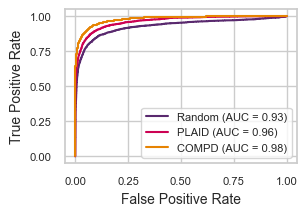

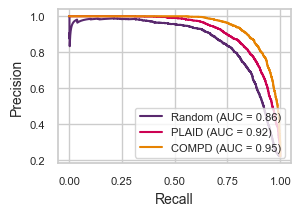

Mean and std of RANDOM layouts: 0.93  $\pm$ (0.003)
Mean and std of PLAID layouts: 0.96  $\pm$ (0.002)
Mean and std of COMPD layouts: 0.98  $\pm$ (0.001)

Variance of RANDOM layouts: 1.0854620290799785e-05
Variance of PLAID layouts: 4.16140638639306e-06
Variance of COMPD layouts: 5.316418809706278e-07 

Case of equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=27.602082542799348, pvalue=3.483868378009669e-16, df=18.0)
RANDOM vs COMPD layouts: TtestResult(statistic=45.04528795824049, pvalue=5.851180627941114e-20, df=18.0)
PLAID vs COMPD layouts: TtestResult(statistic=-20.790428261912975, pvalue=4.92803457522761e-14, df=18.0) 

Case of not equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=27.602082542799355, pvalue=2.7707601303099216e-14, df=15.016488394120545)
RANDOM vs COMPD layouts: TtestResult(statistic=45.04528795824049, pvalue=9.132086391825816e-13, df=9.879501290458794)
PLAID vs COMPD layouts: TtestResult(statistic=-20.790428261912975, pvalue=2.4423329051

In [24]:
# In the supplement, Figure 23b
residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.8-20250623-ROC-supplement.csv'

fig_name = '10-10-0.2-20.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=2)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=2)

util.roc_table_code(residuals_filename)
print('--------------')
util.pr_table_code(residuals_filename)

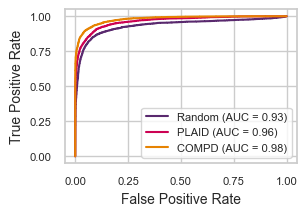

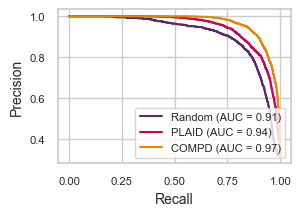

Mean and std of RANDOM layouts: 0.93  $\pm$ (0.002)
Mean and std of PLAID layouts: 0.96  $\pm$ (0.002)
Mean and std of COMPD layouts: 0.98  $\pm$ (0.001)

Variance of RANDOM layouts: 5.070824430392542e-06
Variance of PLAID layouts: 3.7152278003441225e-06
Variance of COMPD layouts: 2.0817325463036325e-06 

Case of equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=36.54683347090265, pvalue=2.4250682379153416e-18, df=18.0)
RANDOM vs COMPD layouts: TtestResult(statistic=58.07361491212645, pvalue=6.227909674910784e-22, df=18.0)
PLAID vs COMPD layouts: TtestResult(statistic=-19.514215058321195, pvalue=1.4719537756845722e-13, df=18.0) 

Case of not equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=36.54683347090265, pvalue=4.938766454917657e-18, df=17.581468126663637)
RANDOM vs COMPD layouts: TtestResult(statistic=58.07361491212646, pvalue=2.1841453133198415e-19, df=15.323780131256202)
PLAID vs COMPD layouts: TtestResult(statistic=-19.514215058321195, pvalue=6.448240

In [25]:
# In the supplement, Figure 23c 
residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.7-20250623-ROC-supplement.csv'

fig_name = '10-10-0.2-30.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir,batch=6)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir,batch=6)

util.roc_table_code(residuals_filename)
print('--------------')
util.pr_table_code(residuals_filename)

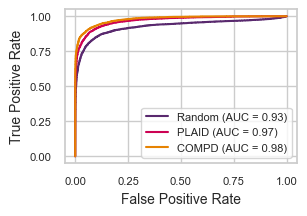

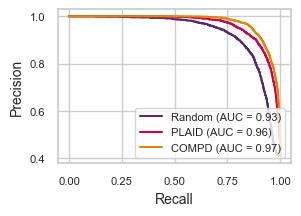

Mean and std of RANDOM layouts: 0.93  $\pm$ (0.003)
Mean and std of PLAID layouts: 0.97  $\pm$ (0.002)
Mean and std of COMPD layouts: 0.98  $\pm$ (0.001)

Variance of RANDOM layouts: 8.502418490094867e-06
Variance of PLAID layouts: 2.710727952065683e-06
Variance of COMPD layouts: 1.5885599226006984e-06 

Case of equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=33.79246288334381, pvalue=9.747520693296558e-18, df=18.0)
RANDOM vs COMPD layouts: TtestResult(statistic=49.684585200519074, pvalue=1.0156864160878032e-20, df=18.0)
PLAID vs COMPD layouts: TtestResult(statistic=-21.54452633291334, pvalue=2.656907874569545e-14, df=18.0) 

Case of not equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=33.79246288334381, pvalue=5.590196583275471e-15, df=14.209238143007264)
RANDOM vs COMPD layouts: TtestResult(statistic=49.684585200519074, pvalue=1.6720903058671935e-15, df=12.249615496747273)
PLAID vs COMPD layouts: TtestResult(statistic=-21.54452633291334, pvalue=1.05924871

In [26]:
# In the supplement, Figure 23d
residuals_filename = data_dir+'screening-residuals-10-10-0.2-pna-0.6-20250623-ROC-supplement.csv'

fig_name = '10-10-0.2-40.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir)

util.roc_table_code(residuals_filename)
print('--------------')
util.pr_table_code(residuals_filename)

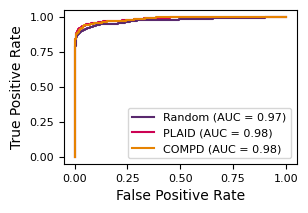

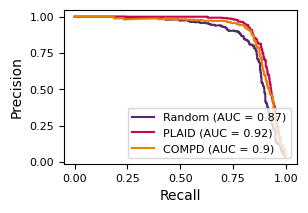

In [42]:
# In the supplement, Figure 24a
residuals_filename = data_dir+'screening-residuals-8-8-0.1-pna-0.99-20250623-ROC-supplement.csv'

fig_name = '8-8-0.1-1.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir)

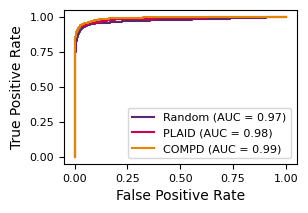

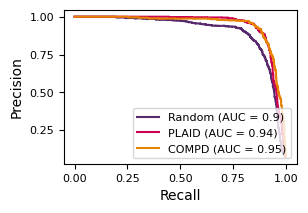

In [52]:
# In the supplement, Figure 24b 
residuals_filename = data_dir+'screening-residuals-8-8-0.1-pna-0.95-20250623-ROC-supplement.csv'

fig_name = '8-8-0.1-5.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=1)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=1)

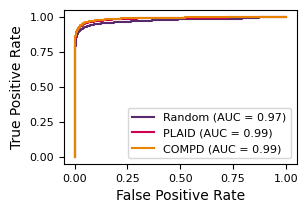

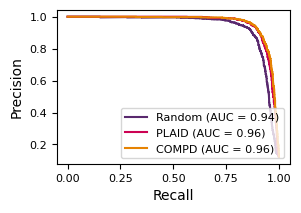

In [50]:
# In the supplement, Figure 24c 
residuals_filename = data_dir+'screening-residuals-8-8-0.1-pna-0.9-20250623-ROC-supplement.csv'

fig_name = '8-8-0.1-10.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=6)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=6)

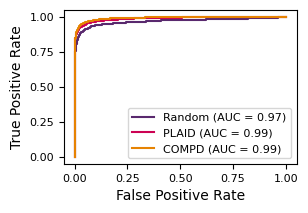

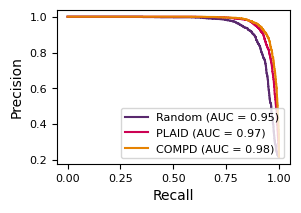

In [48]:
# In the supplement, Figure 24d 
residuals_filename = data_dir+'screening-residuals-8-8-0.1-pna-0.8-20250623-ROC-supplement.csv'

fig_name = '8-8-0.1-20.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=6)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=6)

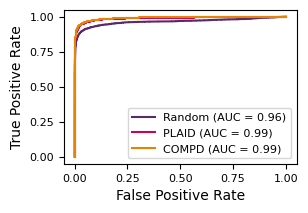

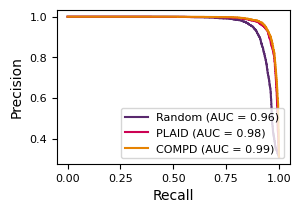

In [46]:
# In the supplement, Figure 24e 
residuals_filename = data_dir+'screening-residuals-8-8-0.1-pna-0.7-20250623-ROC-supplement.csv'

fig_name = '8-8-0.1-30.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=6)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=6)

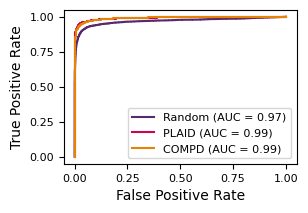

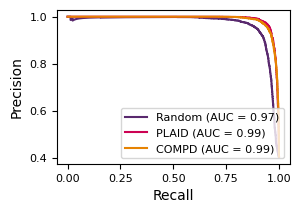

Mean and std of RANDOM layouts: 0.97  $\pm$ (0.002)
Mean and std of PLAID layouts: 0.99  $\pm$ (0.001)
Mean and std of COMPD layouts: 0.99  $\pm$ (0.001)

Variance of RANDOM layouts: 4.8259233321003465e-06
Variance of PLAID layouts: 1.0986237512845508e-06
Variance of COMPD layouts: 9.344807802900138e-07 

Case of equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=23.24936453836009, pvalue=7.05799334583827e-15, df=18.0)
RANDOM vs COMPD layouts: TtestResult(statistic=25.384797842483632, pvalue=1.517377066614596e-15, df=18.0)
PLAID vs COMPD layouts: TtestResult(statistic=-3.040800929127247, pvalue=0.007032105251518891, df=18.0) 

Case of not equal variance:
PLAID vs RANDOM layouts: TtestResult(statistic=23.24936453836009, pvalue=6.5433126784220545e-12, df=12.895809292862724)
RANDOM vs COMPD layouts: TtestResult(statistic=25.384797842483636, pvalue=4.87728640744623e-12, df=12.35951211300845)
PLAID vs COMPD layouts: TtestResult(statistic=-3.0408009291272475, pvalue=0.00707058951

In [44]:
# In the supplement, Figure 24f
residuals_filename = data_dir+'screening-residuals-8-8-0.1-pna-0.6-20250623-ROC-supplement.csv'

fig_name = '8-8-0.1-40.png'

util.plot_roc_curves(residuals_filename, 'ROC-'+fig_name, fig_dir, batch=3)
util.plot_pr_curves(residuals_filename, 'PR-'+fig_name, fig_dir, batch=3)

util.pr_table_code(residuals_filename)

# The End! :-)